In [2]:
pip install pyarrow


   ---------------------------------------- 0.0/28.6 MB ? eta -:--:--
    --------------------------------------- 0.5/28.6 MB 6.7 MB/s eta 0:00:05
   ---- ----------------------------------- 3.4/28.6 MB 11.4 MB/s eta 0:00:03
   -------- ------------------------------- 5.8/28.6 MB 11.5 MB/s eta 0:00:02
   ----------- ---------------------------- 8.4/28.6 MB 11.7 MB/s eta 0:00:02
   --------------- ------------------------ 11.3/28.6 MB 11.9 MB/s eta 0:00:02
   ------------------- -------------------- 13.9/28.6 MB 12.0 MB/s eta 0:00:02
   ---------------------- ----------------- 16.3/28.6 MB 12.1 MB/s eta 0:00:02
   -------------------------- ------------- 19.1/28.6 MB 12.1 MB/s eta 0:00:01
   ------------------------------ --------- 21.8/28.6 MB 12.2 MB/s eta 0:00:01
   --------------------------------- ------ 24.1/28.6 MB 12.2 MB/s eta 0:00:01
   ------------------------------------- -- 26.7/28.6 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------  28.6/28.6 MB 12.2 MB/s

In [3]:
import pyarrow

In [7]:
print(df.dtypes)

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object


In [8]:
missing = df.isnull().sum()
print(missing[missing > 0])

passenger_count         185610
RatecodeID              185610
store_and_fwd_flag      185610
congestion_surcharge    185610
Airport_fee             185610
dtype: int64


In [9]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 1


In [10]:
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

423.989485 MB


In [11]:
df = df.drop_duplicates()

In [14]:
from pathlib import Path

folder = Path("C:/DataAnalytics/NYC_Taxi_Analysis/data/raw")
files = sorted(folder.glob("*.parquet"))
print(f"Found {len(files)} files:")
for f in files:
    print(f"  {f.name}")

parts = []
for f in files:
    tmp = pd.read_parquet(f)
    tmp["month"] = f.stem          # e.g. "2025-01", "2025-02", ...
    parts.append(tmp)

df = pd.concat(parts, ignore_index=True)
print(df.shape)
print(df["month"].value_counts().sort_index()) 

Found 12 files:
  yellow_tripdata_2024-01.parquet
  yellow_tripdata_2024-02.parquet
  yellow_tripdata_2024-03.parquet
  yellow_tripdata_2024-04.parquet
  yellow_tripdata_2024-05.parquet
  yellow_tripdata_2024-06.parquet
  yellow_tripdata_2024-07.parquet
  yellow_tripdata_2024-08.parquet
  yellow_tripdata_2024-09.parquet
  yellow_tripdata_2024-10.parquet
  yellow_tripdata_2024-11.parquet
  yellow_tripdata_2024-12.parquet
(41169720, 20)
month
yellow_tripdata_2024-01    2964624
yellow_tripdata_2024-02    3007526
yellow_tripdata_2024-03    3582628
yellow_tripdata_2024-04    3514289
yellow_tripdata_2024-05    3723833
yellow_tripdata_2024-06    3539193
yellow_tripdata_2024-07    3076903
yellow_tripdata_2024-08    2979183
yellow_tripdata_2024-09    3633030
yellow_tripdata_2024-10    3833771
yellow_tripdata_2024-11    3646369
yellow_tripdata_2024-12    3668371
Name: count, dtype: int64


In [16]:
parts = []
for f in files:
    tmp = pd.read_parquet(f)
    tmp["month"] = f.stem
    parts.append(tmp)

df = pd.concat(parts, ignore_index=True)
print(df.shape)
print(df["month"].value_counts().sort_index())   

(41169720, 20)
month
yellow_tripdata_2024-01    2964624
yellow_tripdata_2024-02    3007526
yellow_tripdata_2024-03    3582628
yellow_tripdata_2024-04    3514289
yellow_tripdata_2024-05    3723833
yellow_tripdata_2024-06    3539193
yellow_tripdata_2024-07    3076903
yellow_tripdata_2024-08    2979183
yellow_tripdata_2024-09    3633030
yellow_tripdata_2024-10    3833771
yellow_tripdata_2024-11    3646369
yellow_tripdata_2024-12    3668371
Name: count, dtype: int64


In [17]:
print(df.dtypes)

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
month                               str
dtype: object


In [18]:
print(missing[missing > 0])

passenger_count         185610
RatecodeID              185610
store_and_fwd_flag      185610
congestion_surcharge    185610
Airport_fee             185610
dtype: int64


In [19]:
# Confirm they're the same rows
mask = df["passenger_count"].isnull()
print(df.loc[mask, "RatecodeID"].isnull().all())   # True → same rows
print(df.loc[mask, "month"].value_counts())          # spread across months? or one?   

True
month
yellow_tripdata_2024-09    483731
yellow_tripdata_2024-03    426190
yellow_tripdata_2024-06    410781
yellow_tripdata_2024-04    408576
yellow_tripdata_2024-05    404666
yellow_tripdata_2024-10    393895
yellow_tripdata_2024-11    373674
yellow_tripdata_2024-12    326291
yellow_tripdata_2024-07    278989
yellow_tripdata_2024-08    258667
yellow_tripdata_2024-02    185610
yellow_tripdata_2024-01    140162
Name: count, dtype: int64


In [20]:
df["passenger_count"] = df["passenger_count"].fillna(1)  # mode is 1 for yellow cabs
df["RatecodeID"] = df["RatecodeID"].fillna(1)            # 1 = standard metered
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("N")
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(0)
df["Airport_fee"] = df["Airport_fee"].fillna(0)

# Verify
print(df.isnull().sum()[lambda s: s > 0])  # should be empty   

Series([], dtype: int64)


In [21]:
print(f"Duplicates: {df.duplicated().sum()}")


Duplicates: 4


In [22]:
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

7086.338193 MB


In [23]:
df = df.drop_duplicates()
print(df.shape)   

(41169716, 20)


In [24]:

print(df.columns.tolist())
print(df.dtypes)


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype) == "category"]

print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")   

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'month']
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount            

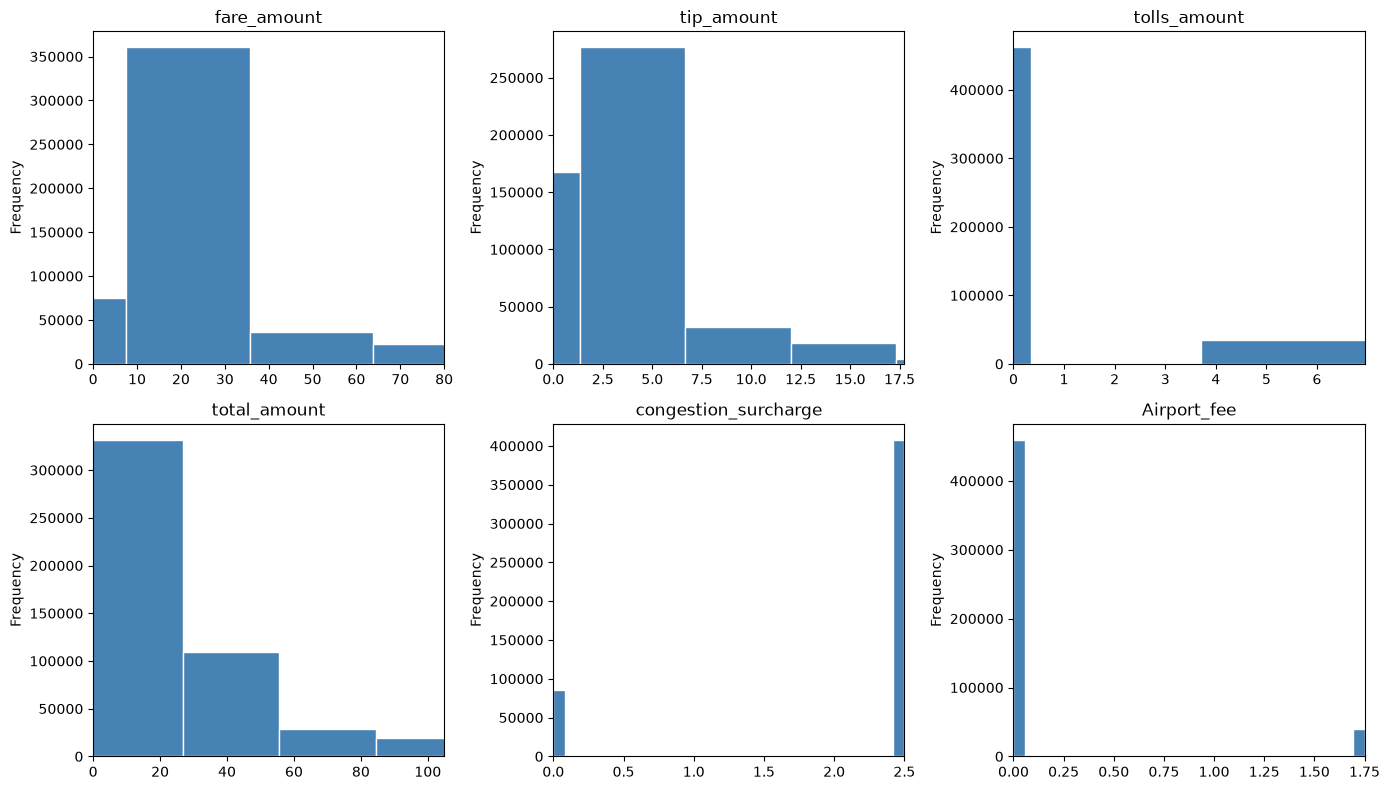

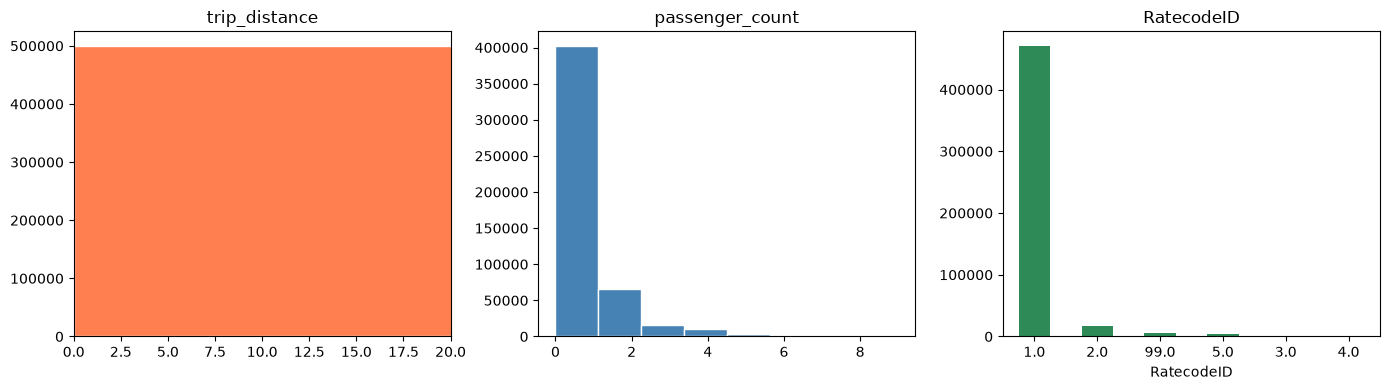

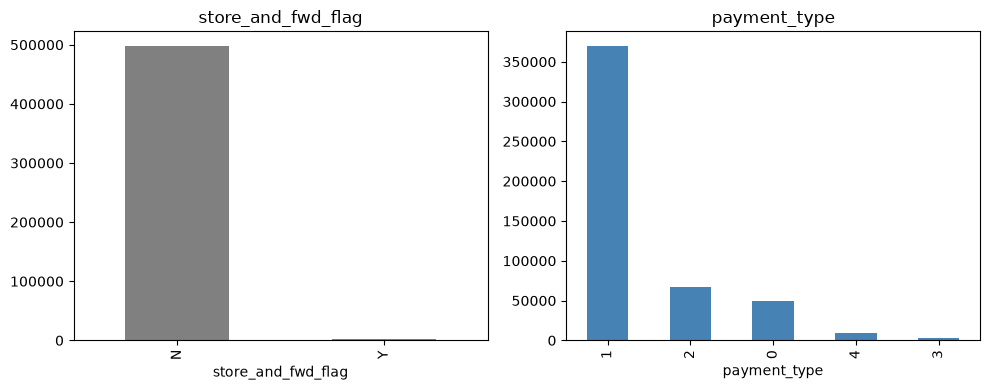

In [25]:
sample = df.sample(n=500_000, random_state=42)

# --- Money columns (the interesting ones) ---
money_cols = ["fare_amount", "tip_amount", "tolls_amount",
              "total_amount", "congestion_surcharge", "Airport_fee"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(money_cols):
    ax = axes[i // 3, i % 3]
    sample[col].plot.hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlim(0, sample[col].quantile(0.99))
plt.tight_layout()
plt.show()

# --- Trip characteristics ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(sample["trip_distance"], bins=60, color="coral", edgecolor="white")
axes[0].set_xlim(0, sample["trip_distance"].quantile(0.99))
axes[0].set_title("trip_distance")

axes[1].hist(sample["passenger_count"], bins=8, color="steelblue", edgecolor="white")
axes[1].set_title("passenger_count")

sample["RatecodeID"].value_counts().plot.bar(ax=axes[2], color="seagreen")
axes[2].set_title("RatecodeID")
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# --- Categorical ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sample["store_and_fwd_flag"].value_counts().plot.bar(ax=axes[0], color="gray")
axes[0].set_title("store_and_fwd_flag")
sample["payment_type"].value_counts().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("payment_type")
plt.tight_layout()
plt.show()   

In [31]:
num_cols = df.select_dtypes(include=[np.number]).columns

In [33]:
cat_cols = df.select_dtypes(include=["object", "category", "str"]).columns.tolist()   

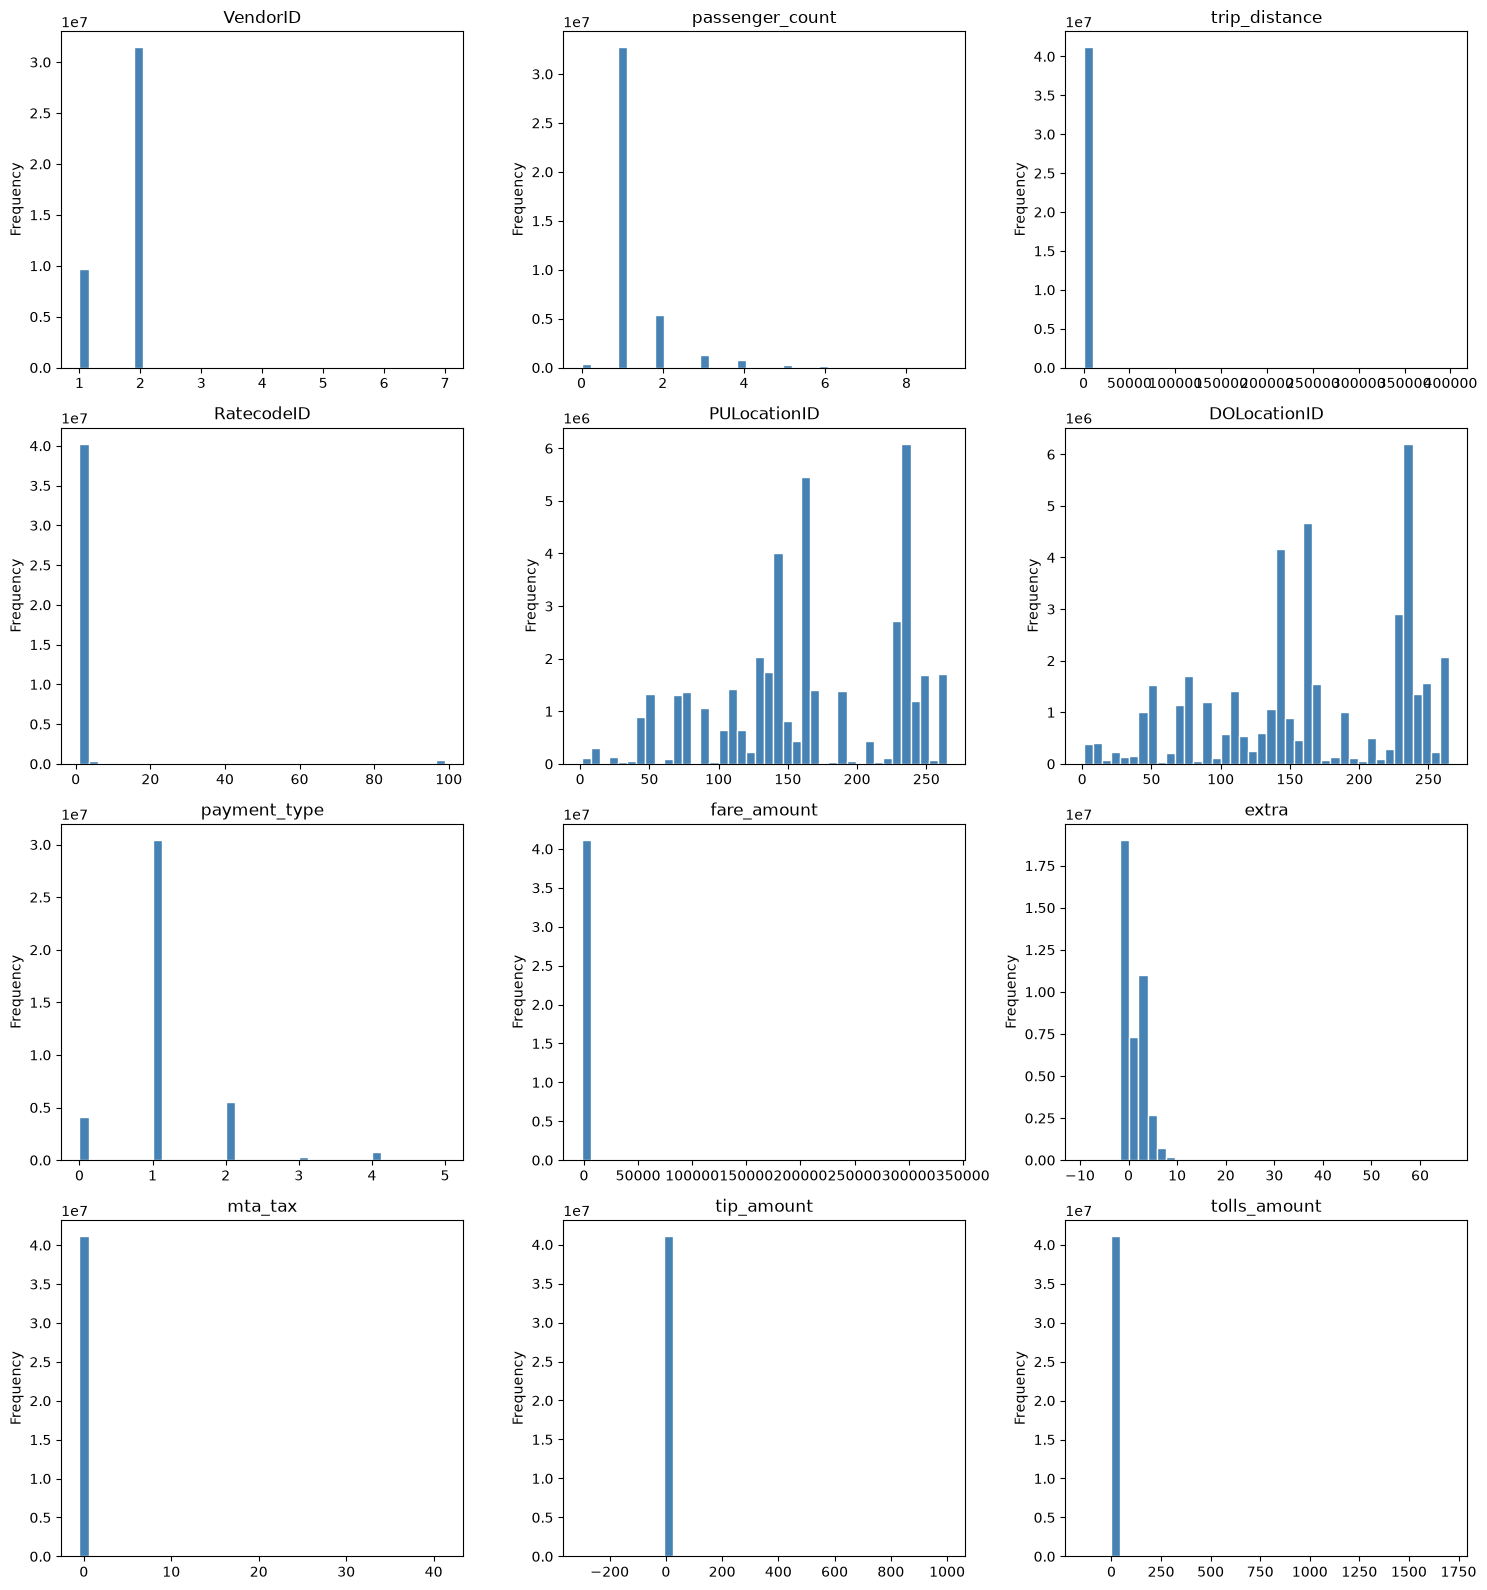

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for i, col in enumerate(num_cols[:12]):
    ax = axes[i // 3, i % 3]
    df[col].plot.hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

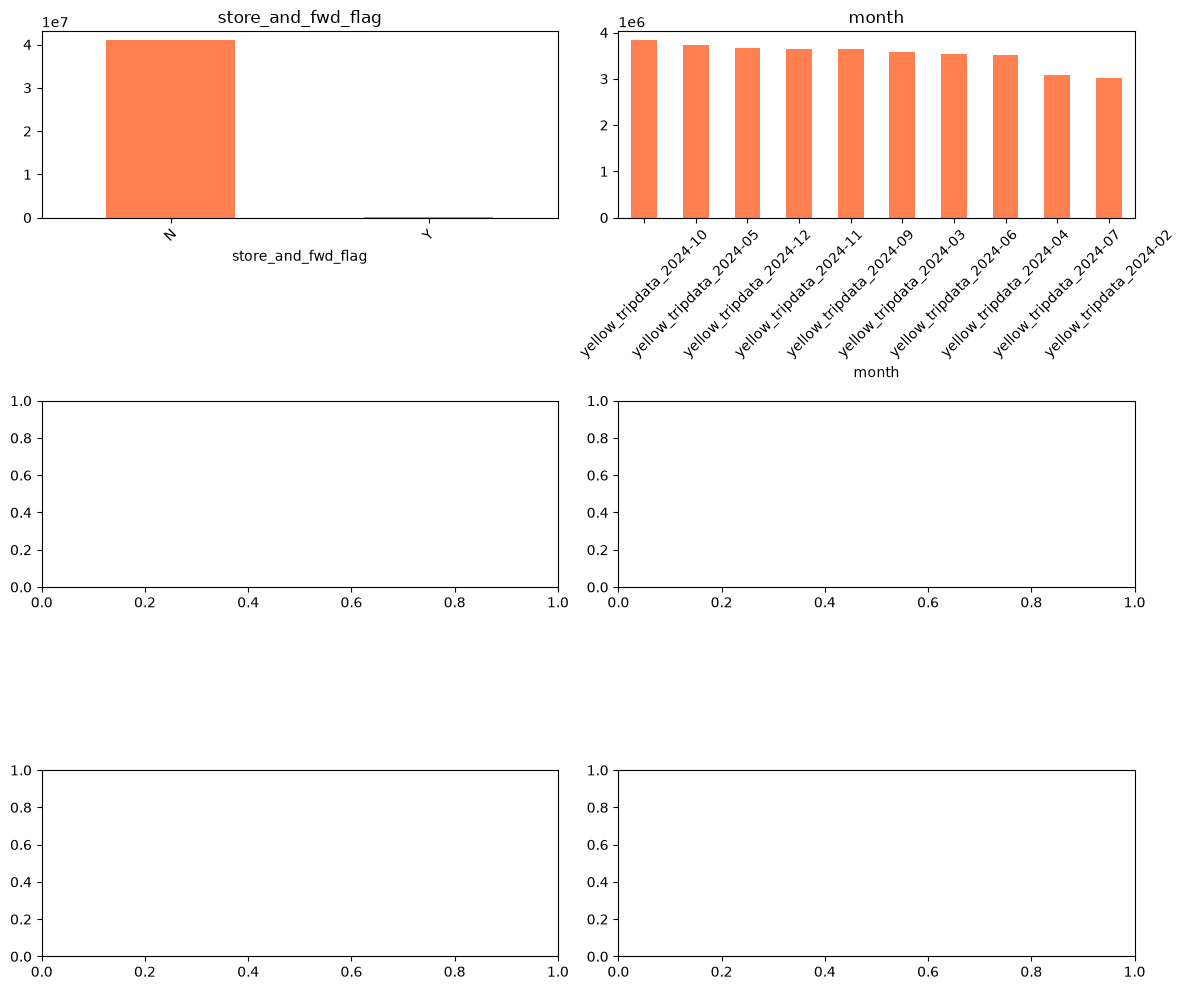

In [35]:
# --- Categorical: top-N bar charts ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, col in enumerate(cat_cols[:6]):
    ax = axes[i // 2, i % 2]
    df[col].value_counts().head(10).plot.bar(ax=ax, color="coral")
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

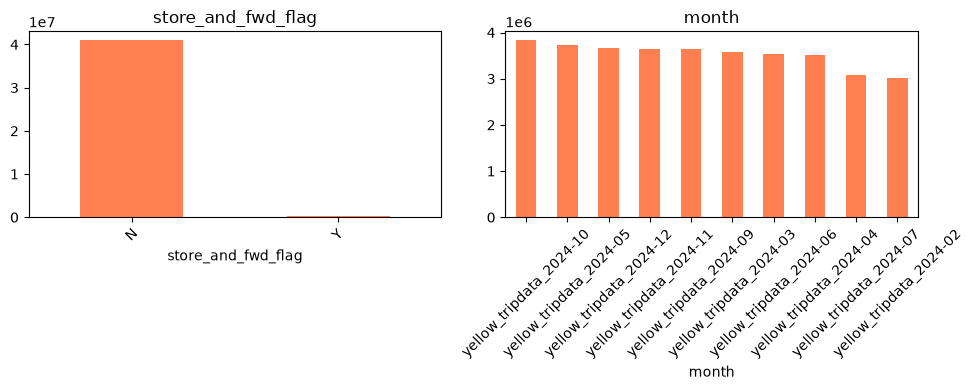

In [36]:
n = len(cat_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]
for i, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot.bar(ax=axes[i], color="coral")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()   

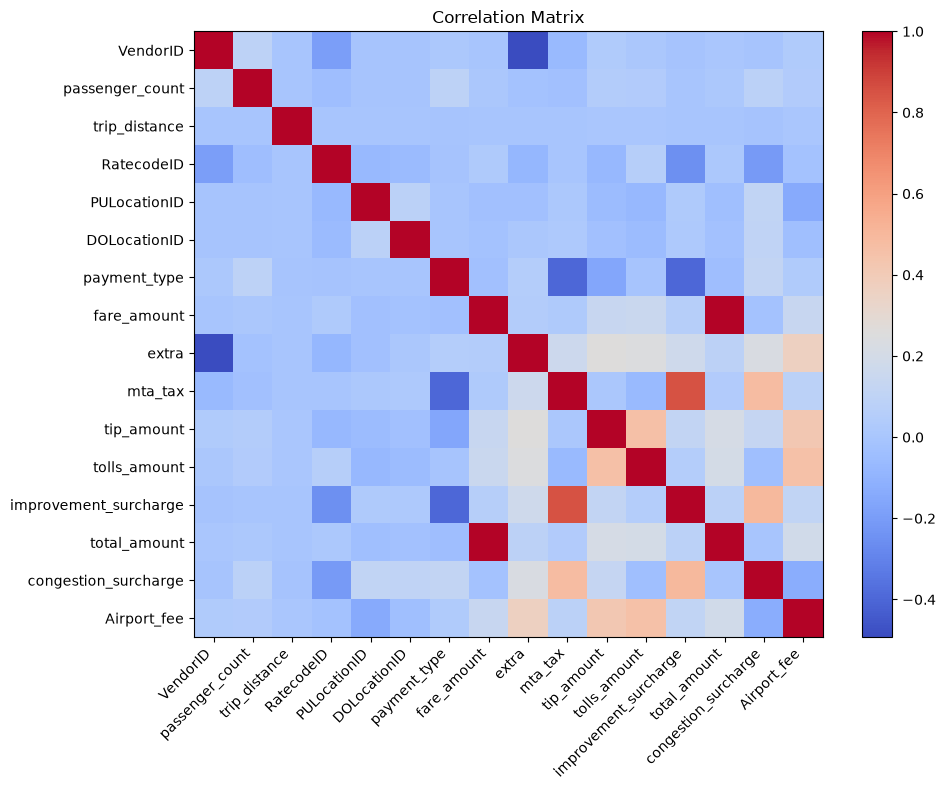

In [37]:
# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.index)
plt.tight_layout()
plt.show()

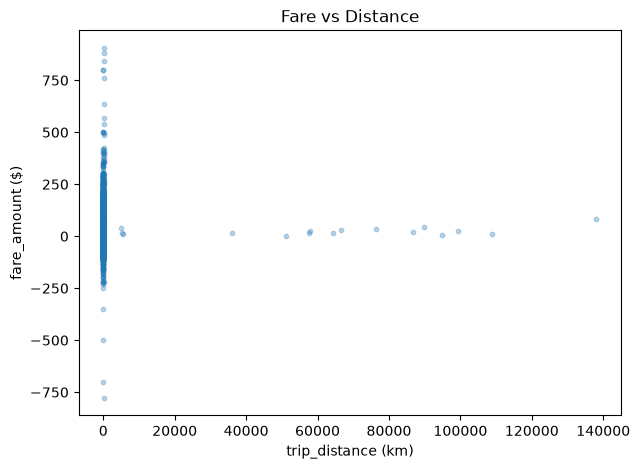

In [39]:
# Fare vs distance (the classic)
sample = df.sample(n=500_000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(sample["trip_distance"], sample["fare_amount"], alpha=0.3, s=10)
plt.xlabel("trip_distance (km)"); plt.ylabel("fare_amount ($)")
plt.title("Fare vs Distance")
plt.show()

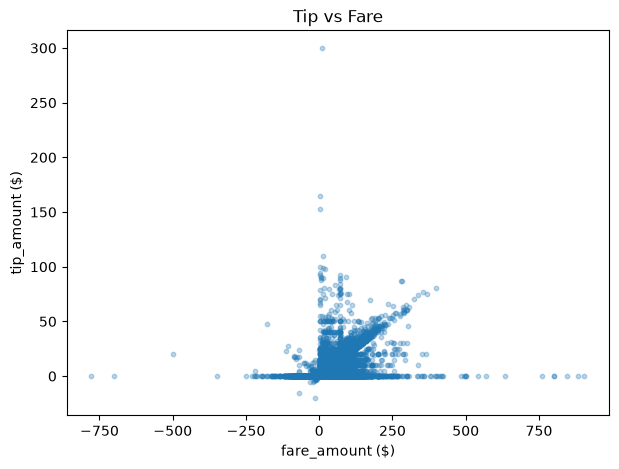

In [40]:
# Tip vs fare (is tip proportional?)
plt.figure(figsize=(7, 5))
plt.scatter(sample["fare_amount"], sample["tip_amount"], alpha=0.3, s=10)
plt.xlabel("fare_amount ($)"); plt.ylabel("tip_amount ($)")
plt.title("Tip vs Fare")
plt.show()

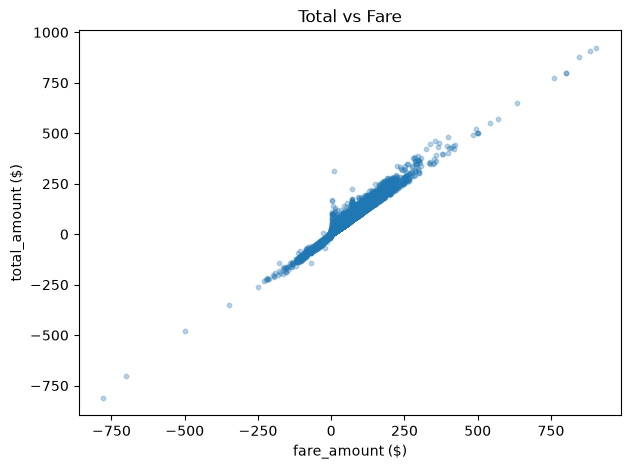

In [41]:
# Total vs fare (what's adding to the total?)
plt.figure(figsize=(7, 5))
plt.scatter(sample["fare_amount"], sample["total_amount"], alpha=0.3, s=10)
plt.xlabel("fare_amount ($)"); plt.ylabel("total_amount ($)")
plt.title("Total vs Fare")
plt.show()

In [46]:
# IQR-based outlier count per numeric column
outliers = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers[col] = int(((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum())

print(pd.Series(outliers).sort_values(ascending=False).head(10))

payment_type            10717559
VendorID                 9718216
passenger_count          8445784
congestion_surcharge     7568174
trip_distance            5259982
total_amount             5029569
fare_amount              4181625
Airport_fee              3313232
tolls_amount             3135484
RatecodeID               2427461
dtype: int64


In [47]:
df = pd.read_parquet(
    r"C:\DataAnalytics\NYC_Taxi_Analysis\data\raw\yellow_tripdata_2024-01.parquet")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 2,964,624 rows × 19 columns


In [48]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [49]:
print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])


=== DATA TYPES ===
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

=== MISSING VALUES ===
                      Missing_Count  Percentage
store_and_fwd_flag           140162    4.727817
RatecodeID                   140162    4.727817
passenger_count              140162   

In [50]:
# Check if missing values are from specific dates or vendors
missing_rows = df[df['passenger_count'].isnull()]

print("=== MISSING DATA ANALYSIS ===")
print(f"\nDate range of missing data:")
print(f"  From: {missing_rows['tpep_pickup_datetime'].min()}")
print(f"  To: {missing_rows['tpep_pickup_datetime'].max()}")

print(f"\nVendor distribution in missing data:")
print(missing_rows['VendorID'].value_counts())

print(f"\nAre other important fields present?")
print(f"  Fare amount: {missing_rows['fare_amount'].notna().sum():,} present")
print(f"  Trip distance: {missing_rows['trip_distance'].notna().sum():,} present")
print(f"  Total amount: {missing_rows['total_amount'].notna().sum():,} present")

=== MISSING DATA ANALYSIS ===

Date range of missing data:
  From: 2024-01-01 00:00:58
  To: 2024-01-31 23:58:25

Vendor distribution in missing data:
VendorID
2    91447
1    48455
6      260
Name: count, dtype: int64

Are other important fields present?
  Fare amount: 140,162 present
  Trip distance: 140,162 present
  Total amount: 140,162 present


In [52]:
print("="*60)
print("STEP 4: HANDLE MISSING VALUES")
print("="*60)

# Investigate the pattern
missing_rows = df[df['passenger_count'].isnull()]
print(f"\n📊 Missing data: {len(missing_rows):,} rows ({len(missing_rows)/len(df)*100:.1f}%)")
print(f"   Date range: {missing_rows['tpep_pickup_datetime'].min().date()} to {missing_rows['tpep_pickup_datetime'].max().date()}")
print(f"   Vendors affected: {missing_rows['VendorID'].nunique()} vendors")
print(f"   ✅ Core fields intact: fare, distance, total amount all present")

# Create a clean copy and fill missing values (MODERN WAY - no warnings!)
df_clean = df.copy()

print("\n🔧 Filling missing values with defaults:")
print("   • passenger_count → 1 (most common)")
print("   • RatecodeID → 1 (standard rate)")
print("   • Airport_fee → 0")
print("   • congestion_surcharge → 0")
print("   • store_and_fwd_flag → 'N'")

# Fill all at once - cleaner and more efficient!
df_clean = df_clean.fillna({
    'passenger_count': 1,
    'RatecodeID': 1,
    'Airport_fee': 0,
    'congestion_surcharge': 0,
    'store_and_fwd_flag': 'N'
})

# Verify no more missing values
print(f"\n✅ Missing values after filling: {df_clean.isnull().sum().sum()}")

# Now apply quality filters
print("\n" + "="*60)
print("APPLYING DATA QUALITY FILTERS")
print("="*60)

initial_count = len(df_clean)

df_clean = df_clean[
    (df_clean['fare_amount'] > 0) &
    (df_clean['fare_amount'] < 500) &  # Remove extreme outliers
    (df_clean['trip_distance'] > 0) &
    (df_clean['trip_distance'] < 100) &  # Remove extreme outliers
    (df_clean['passenger_count'] > 0) &
    (df_clean['passenger_count'] <= 6)
]

# Calculate trip duration
df_clean['trip_duration_minutes'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Filter by duration
df_clean = df_clean[
    (df_clean['trip_duration_minutes'] > 0) &
    (df_clean['trip_duration_minutes'] < 180)  # Less than 3 hours
]

removed = initial_count - len(df_clean)
print(f"\n📉 Removed {removed:,} rows with data quality issues ({removed/initial_count*100:.2f}%)")
print(f"✅ Clean dataset: {len(df_clean):,} trips ({len(df_clean)/len(df)*100:.1f}% of original)")

print("\n" + "="*60)
print("DATA QUALITY SUMMARY")
print("="*60)
print(f"Original rows:        {len(df):>12,}")
print(f"After handling nulls: {initial_count:>12,}")
print(f"After quality filters:{len(df_clean):>12,}")
print(f"Final retention rate: {len(df_clean)/len(df)*100:>11.1f}%")
print("="*60)

STEP 4: HANDLE MISSING VALUES

📊 Missing data: 140,162 rows (4.7%)
   Date range: 2024-01-01 to 2024-01-31
   Vendors affected: 3 vendors
   ✅ Core fields intact: fare, distance, total amount all present

🔧 Filling missing values with defaults:
   • passenger_count → 1 (most common)
   • RatecodeID → 1 (standard rate)
   • Airport_fee → 0
   • congestion_surcharge → 0
   • store_and_fwd_flag → 'N'

✅ Missing values after filling: 0

APPLYING DATA QUALITY FILTERS

📉 Removed 127,736 rows with data quality issues (4.31%)
✅ Clean dataset: 2,836,888 trips (95.7% of original)

DATA QUALITY SUMMARY
Original rows:           2,964,624
After handling nulls:    2,964,624
After quality filters:   2,836,888
Final retention rate:        95.7%


In [53]:
print("\n" + "="*60)
print("CLEAN DATA PREVIEW")
print("="*60)

print("\n📊 Basic Statistics:")
print(f"   Total trips: {len(df_clean):,}")
print(f"   Date range: {df_clean['tpep_pickup_datetime'].min().date()} to {df_clean['tpep_pickup_datetime'].max().date()}")
print(f"   Total revenue: ${df_clean['total_amount'].sum():,.2f}")
print(f"   Average fare: ${df_clean['fare_amount'].mean():.2f}")
print(f"   Average distance: {df_clean['trip_distance'].mean():.2f} miles")
print(f"   Average duration: {df_clean['trip_duration_minutes'].mean():.1f} minutes")

print("\n💳 Payment Types:")
print(df_clean['payment_type'].value_counts())

print("\n👥 Passenger Counts:")
print(df_clean['passenger_count'].value_counts().sort_index())

print("\n" + "="*60)


CLEAN DATA PREVIEW

📊 Basic Statistics:
   Total trips: 2,836,888
   Date range: 2002-12-31 to 2024-02-01
   Total revenue: $77,616,795.97
   Average fare: $18.50
   Average distance: 3.30 miles
   Average duration: 15.0 minutes

💳 Payment Types:
payment_type
1    2272102
2     417221
0     115172
4      22599
3       9794
Name: count, dtype: int64

👥 Passenger Counts:
passenger_count
1.0    2248350
2.0     394847
3.0      88914
4.0      49536
5.0      33164
6.0      22077
Name: count, dtype: int64



In [55]:
print("\n" + "="*60)
print("STEP 5: FEATURE ENGINEERING")
print("="*60)

# Extract time-based features from the datetime columns
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['pickup_day'] = df_clean['tpep_pickup_datetime'].dt.day
df_clean['pickup_dayofweek'] = df_clean['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['pickup_date'] = df_clean['tpep_pickup_datetime'].dt.date
df_clean['is_weekend'] = df_clean['pickup_dayofweek'].isin([5, 6])

# Calculate additional metrics
df_clean['total_amount_per_mile'] = df_clean['total_amount'] / df_clean['trip_distance']
df_clean['tip_percentage'] = (df_clean['tip_amount'] / df_clean['fare_amount'] * 100).clip(0, 100)
df_clean['speed_mph'] = (df_clean['trip_distance'] / (df_clean['trip_duration_minutes'] / 60)).clip(0, 60)

# Day name for better readability
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df_clean['day_name'] = df_clean['pickup_dayofweek'].map(day_names)

print("\n✅ Feature engineering complete!")
print(f"Total columns now: {len(df_clean.columns)}")

# Verify the new columns exist
print("\n📋 New columns created:")
new_cols = ['pickup_hour', 'pickup_day', 'pickup_dayofweek', 'pickup_date', 
            'is_weekend', 'total_amount_per_mile', 'tip_percentage', 'speed_mph', 'day_name']
for col in new_cols:
    if col in df_clean.columns:
        print(f"   ✅ {col}")
    else:
        print(f"   ❌ {col} - MISSING!")

print("\n" + "="*60)


STEP 5: FEATURE ENGINEERING

✅ Feature engineering complete!
Total columns now: 29

📋 New columns created:
   ✅ pickup_hour
   ✅ pickup_day
   ✅ pickup_dayofweek
   ✅ pickup_date
   ✅ is_weekend
   ✅ total_amount_per_mile
   ✅ tip_percentage
   ✅ speed_mph
   ✅ day_name




STEP 6: TEMPORAL ANALYSIS - HOURLY PATTERNS

📊 Hourly Statistics:
             trip_count  fare_amount  trip_distance  tip_amount
pickup_hour                                                    
0                 74448    19.689377       3.854671    3.421526
1                 49981    17.727338       3.263512    3.037705
2                 34541    16.623204       3.035647    2.890477
3                 22682    18.539740       3.517049    2.940984
4                 15126    23.443189       4.865815    3.314607
5                 17341    27.528789       6.233229    3.961212
6                 39019    22.013910       4.724131    3.232103
7                 79818    18.755657       3.562663    3.142495
8                111982    17.844173       3.063341    3.117854
9                123963    17.960386       3.052527    3.211145
10               133695    18.058716       3.054660    3.210987
11               144928    17.647925       2.913398    3.162514
12               157972    17.816000 

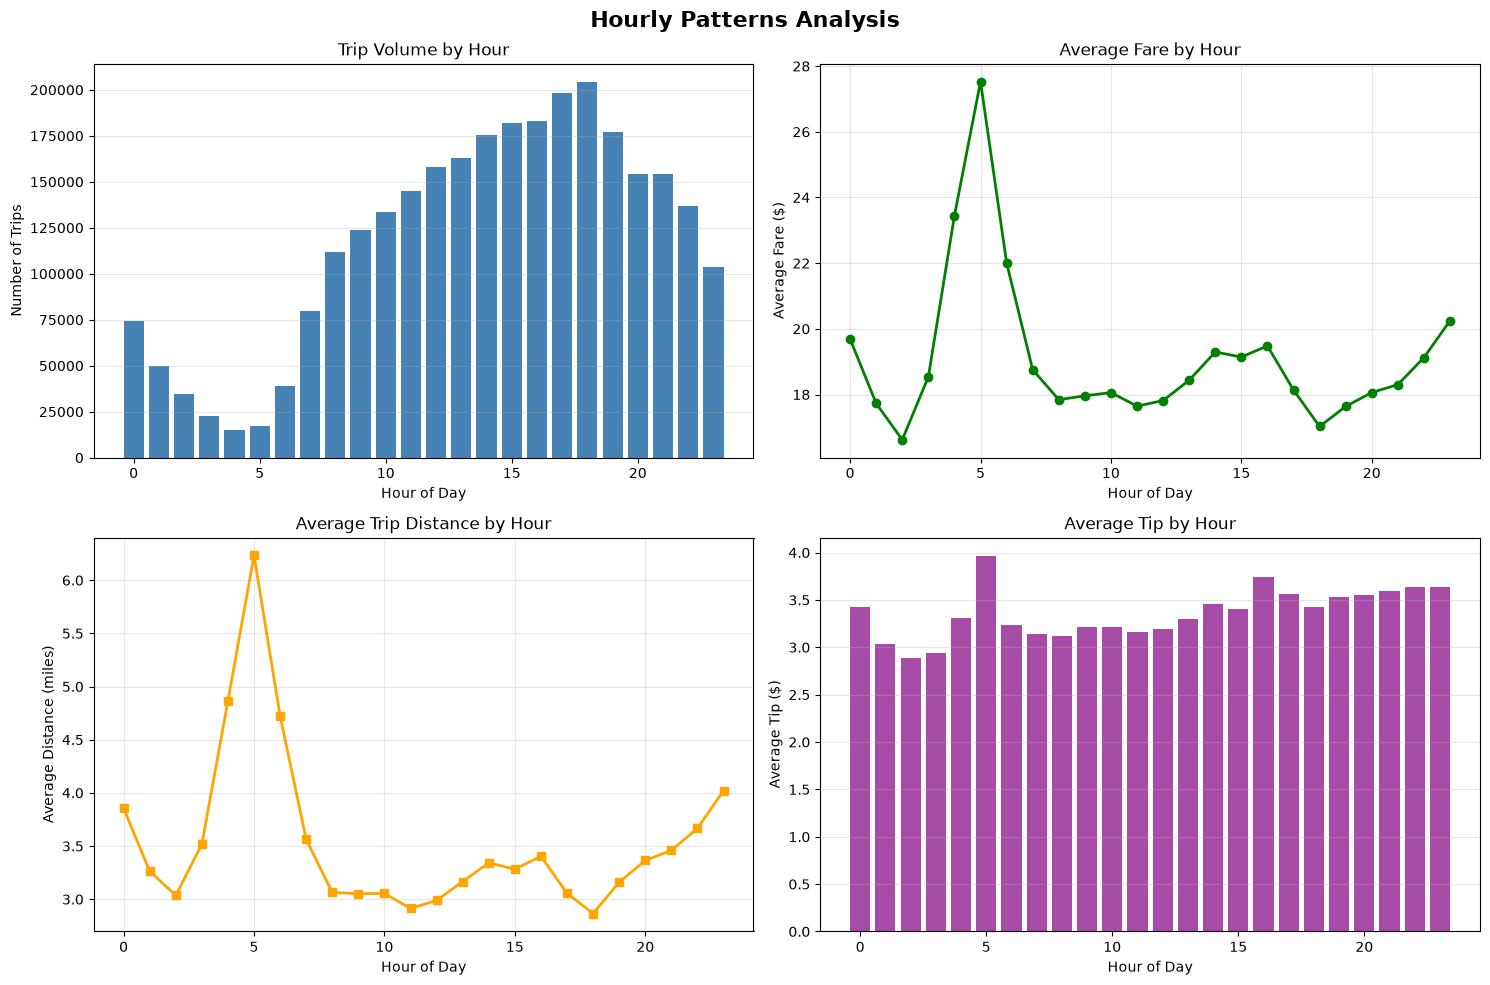


=== PEAK HOURS ===
Busiest hour: 18:00 with 204,033 trips
Quietest hour: 4:00 with 15,126 trips
Highest avg fare hour: 5:00 ($27.53)
Longest avg distance hour: 5:00 (6.23 miles)



In [56]:
print("\n" + "="*60)
print("STEP 6: TEMPORAL ANALYSIS - HOURLY PATTERNS")
print("="*60)

# Aggregate by hour
hourly_trips = df_clean.groupby('pickup_hour').agg({
    'VendorID': 'count',
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'tip_amount': 'mean'
}).rename(columns={'VendorID': 'trip_count'})

print("\n📊 Hourly Statistics:")
print(hourly_trips)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Hourly Patterns Analysis', fontsize=16, fontweight='bold')

# Trip count by hour
axes[0, 0].bar(hourly_trips.index, hourly_trips['trip_count'], color='steelblue')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Trips')
axes[0, 0].set_title('Trip Volume by Hour')
axes[0, 0].grid(axis='y', alpha=0.3)

# Average fare by hour
axes[0, 1].plot(hourly_trips.index, hourly_trips['fare_amount'], marker='o', color='green', linewidth=2)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Average Fare ($)')
axes[0, 1].set_title('Average Fare by Hour')
axes[0, 1].grid(alpha=0.3)

# Average distance by hour
axes[1, 0].plot(hourly_trips.index, hourly_trips['trip_distance'], marker='s', color='orange', linewidth=2)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Distance (miles)')
axes[1, 0].set_title('Average Trip Distance by Hour')
axes[1, 0].grid(alpha=0.3)

# Average tip by hour
axes[1, 1].bar(hourly_trips.index, hourly_trips['tip_amount'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Average Tip ($)')
axes[1, 1].set_title('Average Tip by Hour')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== PEAK HOURS ===")
print(f"Busiest hour: {hourly_trips['trip_count'].idxmax()}:00 with {hourly_trips['trip_count'].max():,.0f} trips")
print(f"Quietest hour: {hourly_trips['trip_count'].idxmin()}:00 with {hourly_trips['trip_count'].min():,.0f} trips")
print(f"Highest avg fare hour: {hourly_trips['fare_amount'].idxmax()}:00 (${hourly_trips['fare_amount'].max():.2f})")
print(f"Longest avg distance hour: {hourly_trips['trip_distance'].idxmax()}:00 ({hourly_trips['trip_distance'].max():.2f} miles)")

print("\n" + "="*60)


=== WEEKDAY VS WEEKEND ===
         trip_count  fare_amount  trip_distance  tip_amount  \
Weekday     2111544    18.710527       3.314132    3.460309   
Weekend      725344    17.905404       3.246040    3.247408   

         trip_duration_minutes  
Weekday              15.404204  
Weekend              13.699645  


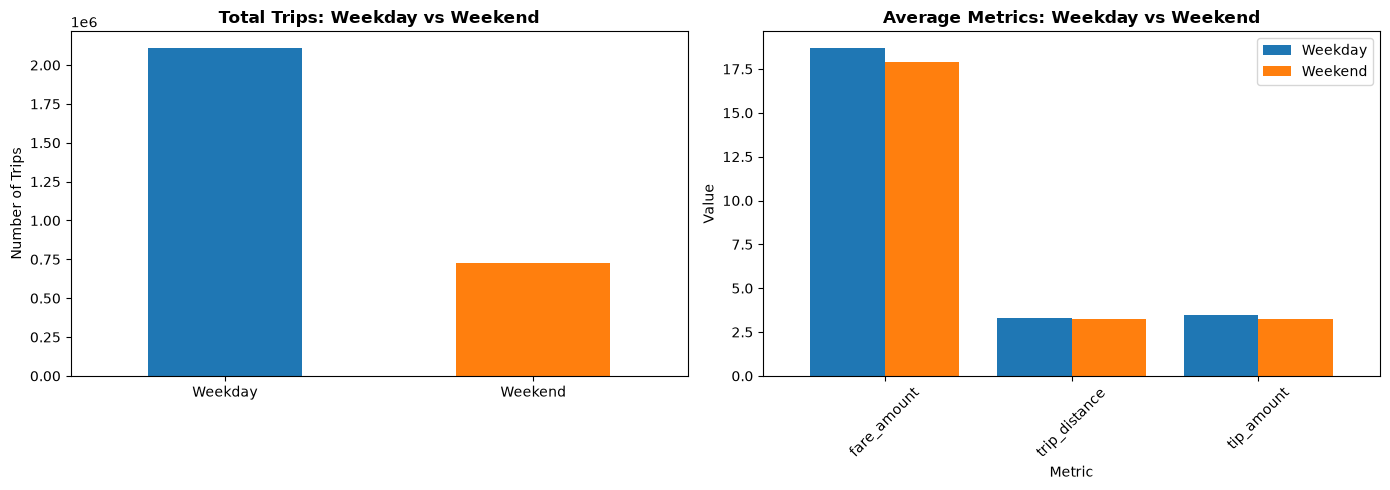

In [58]:
# Compare weekday vs weekend
weekend_comparison = df_clean.groupby('is_weekend').agg({
    'VendorID': 'count',
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'tip_amount': 'mean',
    'trip_duration_minutes': 'mean'
}).rename(columns={'VendorID': 'trip_count'})

weekend_comparison.index = ['Weekday', 'Weekend']

print("\n=== WEEKDAY VS WEEKEND ===")
print(weekend_comparison)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip count comparison
weekend_comparison['trip_count'].plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Total Trips: Weekday vs Weekend', fontweight='bold')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Average metrics comparison
metrics = weekend_comparison[['fare_amount', 'trip_distance', 'tip_amount']].T
metrics.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Average Metrics: Weekday vs Weekend', fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Metric')
axes[1].legend(['Weekday', 'Weekend'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


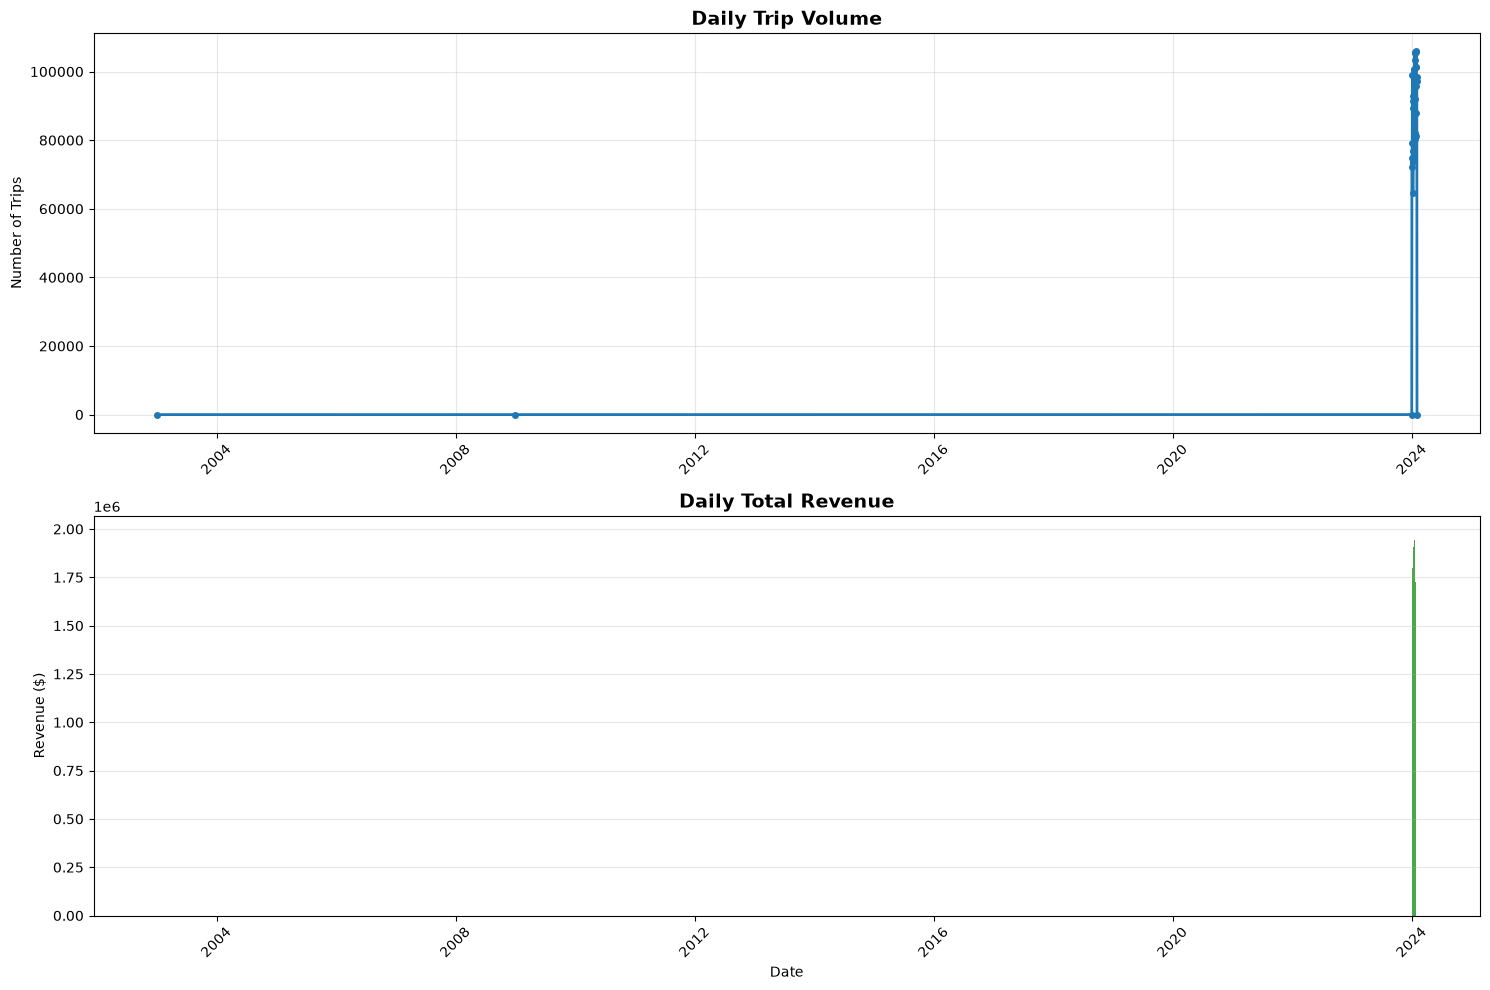


=== DAILY STATISTICS ===
Average daily trips: 81,054
Average daily revenue: $1,499,876.52
Best day: 2024-01-27 with 105,920 trips
Worst day: 2002-12-31 with 1 trips


In [59]:
# Daily aggregation
daily_stats = df_clean.groupby('pickup_date').agg({
    'VendorID': 'count',
    'fare_amount': ['sum', 'mean'],
    'trip_distance': 'mean',
    'tip_amount': 'sum'
}).reset_index()

daily_stats.columns = ['date', 'trip_count', 'total_revenue', 'avg_fare', 'avg_distance', 'total_tips']

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Daily trip volume
axes[0].plot(daily_stats['date'], daily_stats['trip_count'], marker='o', linewidth=2, markersize=4)
axes[0].set_title('Daily Trip Volume', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Daily revenue
axes[1].bar(daily_stats['date'], daily_stats['total_revenue'], color='green', alpha=0.7)
axes[1].set_title('Daily Total Revenue', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Date')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n=== DAILY STATISTICS ===")
print(f"Average daily trips: {daily_stats['trip_count'].mean():,.0f}")
print(f"Average daily revenue: ${daily_stats['total_revenue'].mean():,.2f}")
print(f"Best day: {daily_stats.loc[daily_stats['trip_count'].idxmax(), 'date']} with {daily_stats['trip_count'].max():,.0f} trips")
print(f"Worst day: {daily_stats.loc[daily_stats['trip_count'].idxmin(), 'date']} with {daily_stats['trip_count'].min():,.0f} trips")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26604\2216965100.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean['fare_amount'], vert=True)


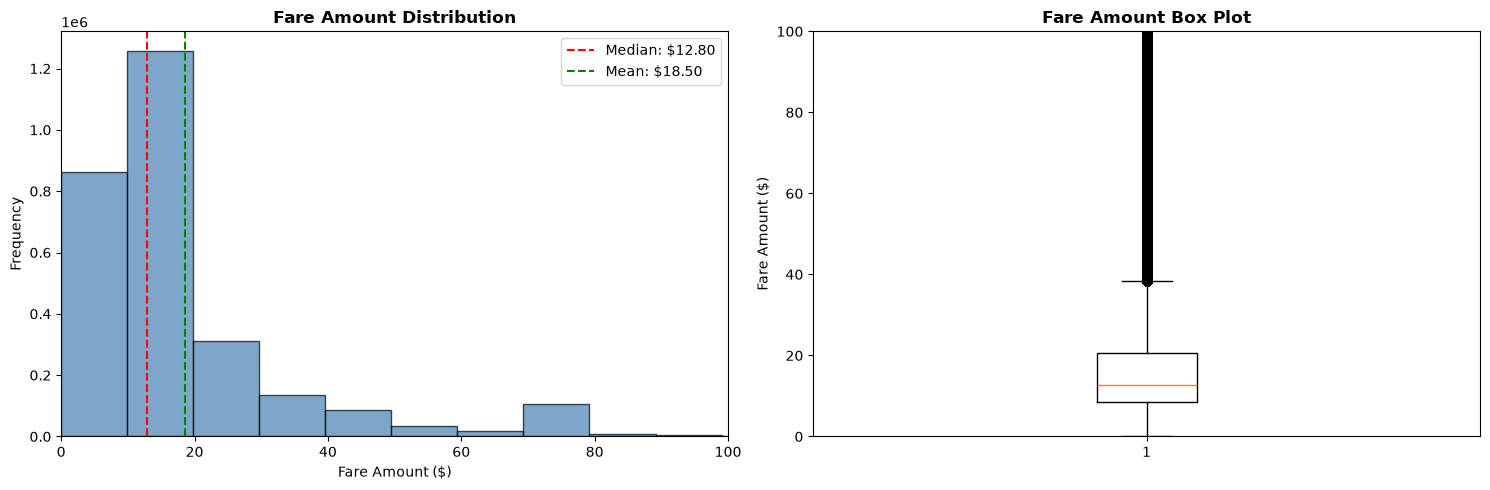


=== FARE STATISTICS ===
count    2.836888e+06
mean     1.850467e+01
std      1.705825e+01
min      1.000000e-02
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      4.951000e+02
Name: fare_amount, dtype: float64


In [60]:
# Fare distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['fare_amount'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Fare Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Fare Amount Distribution', fontweight='bold')
axes[0].axvline(df_clean['fare_amount'].median(), color='red', linestyle='--', label=f"Median: ${df_clean['fare_amount'].median():.2f}")
axes[0].axvline(df_clean['fare_amount'].mean(), color='green', linestyle='--', label=f"Mean: ${df_clean['fare_amount'].mean():.2f}")
axes[0].legend()
axes[0].set_xlim(0, 100)

# Box plot
axes[1].boxplot(df_clean['fare_amount'], vert=True)
axes[1].set_ylabel('Fare Amount ($)')
axes[1].set_title('Fare Amount Box Plot', fontweight='bold')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\n=== FARE STATISTICS ===")
print(df_clean['fare_amount'].describe())


=== PAYMENT TYPE ANALYSIS ===
              trip_count  fare_amount  tip_amount  total_amount
payment_type                                                   
Type 0            115172    20.362418    1.844598    3053942.59
Credit Card      2272102    18.389218    4.158896   63834615.37
Cash              417221    18.587567    0.000142    9943610.11
No Charge           9794    17.161340    0.005404     218350.64
Dispute            22599    19.696363    0.003889     566277.26


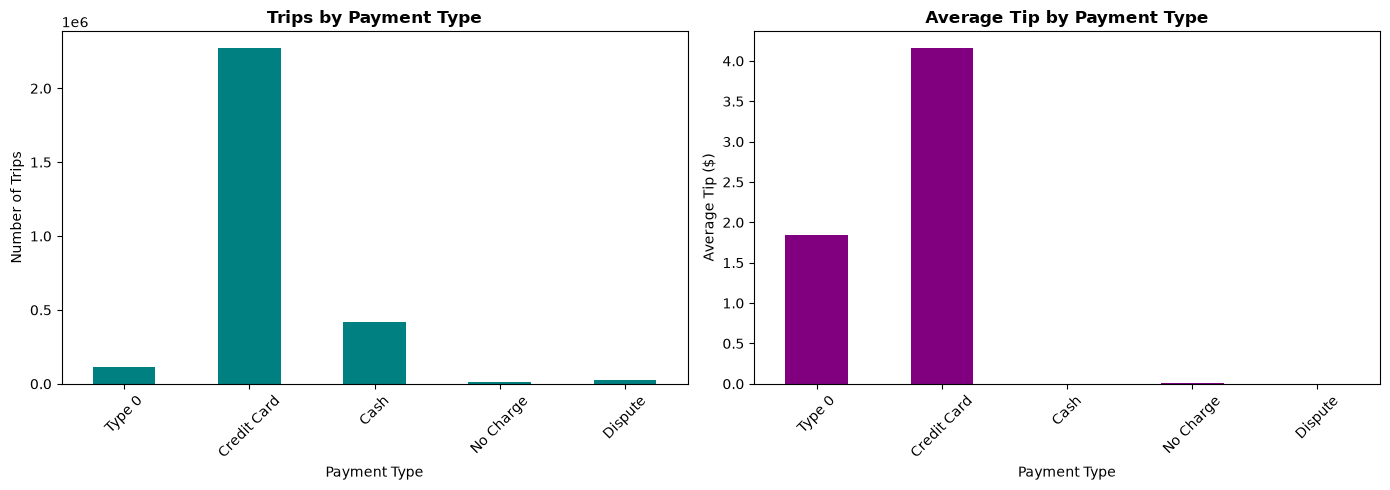

In [61]:
# Payment type breakdown
payment_analysis = df_clean.groupby('payment_type').agg({
    'VendorID': 'count',
    'fare_amount': 'mean',
    'tip_amount': 'mean',
    'total_amount': 'sum'
}).rename(columns={'VendorID': 'trip_count'})

# Map payment types
payment_names = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
payment_analysis.index = payment_analysis.index.map(lambda x: payment_names.get(x, f'Type {x}'))

print("\n=== PAYMENT TYPE ANALYSIS ===")
print(payment_analysis)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip count by payment type
payment_analysis['trip_count'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Trips by Payment Type', fontweight='bold')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xlabel('Payment Type')
axes[0].tick_params(axis='x', rotation=45)

# Average tip by payment type
payment_analysis['tip_amount'].plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Average Tip by Payment Type', fontweight='bold')
axes[1].set_ylabel('Average Tip ($)')
axes[1].set_xlabel('Payment Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


=== TIP ANALYSIS (Credit Card Trips Only) ===
Trips with tips: 2,166,016 (95.3%)
Average tip: $4.16
Average tip percentage: 25.4%


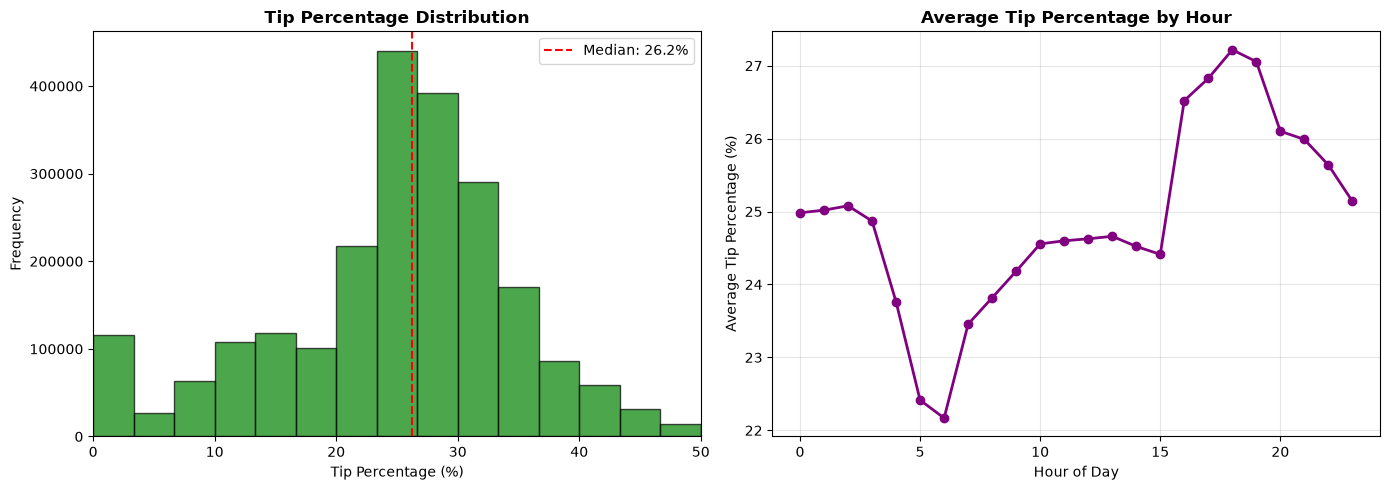

In [62]:
# Tip analysis (credit card only, as cash tips aren't recorded)
credit_card_trips = df_clean[df_clean['payment_type'] == 1].copy()

print("\n=== TIP ANALYSIS (Credit Card Trips Only) ===")
print(f"Trips with tips: {(credit_card_trips['tip_amount'] > 0).sum():,} ({(credit_card_trips['tip_amount'] > 0).sum()/len(credit_card_trips)*100:.1f}%)")
print(f"Average tip: ${credit_card_trips['tip_amount'].mean():.2f}")
print(f"Average tip percentage: {credit_card_trips['tip_percentage'].mean():.1f}%")

# Tip percentage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(credit_card_trips['tip_percentage'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Tip Percentage (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Tip Percentage Distribution', fontweight='bold')
axes[0].axvline(credit_card_trips['tip_percentage'].median(), color='red', linestyle='--', 
                label=f"Median: {credit_card_trips['tip_percentage'].median():.1f}%")
axes[0].legend()
axes[0].set_xlim(0, 50)

# Tip by hour
tip_by_hour = credit_card_trips.groupby('pickup_hour')['tip_percentage'].mean()
axes[1].plot(tip_by_hour.index, tip_by_hour.values, marker='o', linewidth=2, color='purple')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Tip Percentage (%)')
axes[1].set_title('Average Tip Percentage by Hour', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== TRIP DISTANCE STATISTICS ===
count    2.836888e+06
mean     3.296722e+00
std      4.374708e+00
min      1.000000e-02
25%      1.020000e+00
50%      1.700000e+00
75%      3.190000e+00
max      9.750000e+01
Name: trip_distance, dtype: float64


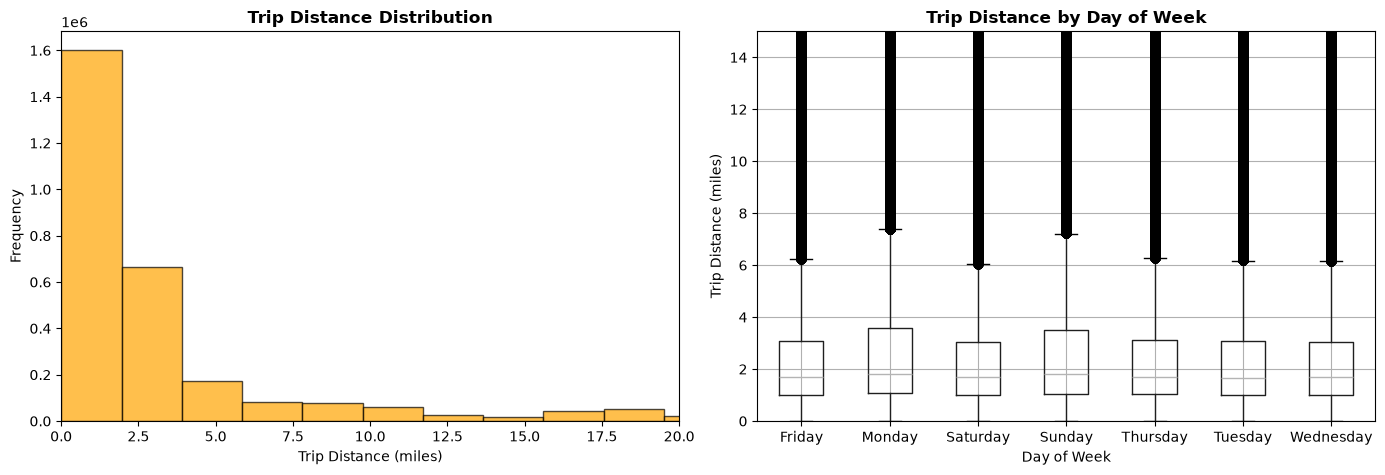

In [63]:
print("\n=== TRIP DISTANCE STATISTICS ===")
print(df_clean['trip_distance'].describe())

# Distance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['trip_distance'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_xlabel('Trip Distance (miles)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Trip Distance Distribution', fontweight='bold')
axes[0].set_xlim(0, 20)

# Box plot by day of week
df_clean.boxplot(column='trip_distance', by='day_name', ax=axes[1])
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Trip Distance (miles)')
axes[1].set_title('Trip Distance by Day of Week', fontweight='bold')
axes[1].set_ylim(0, 15)
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()


=== PASSENGER COUNT ANALYSIS ===
                 trip_count  fare_amount  trip_distance  tip_percentage
passenger_count                                                        
1.0                 2248350    18.016368       3.179396       20.731519
2.0                  394847    20.581149       3.823637       20.671091
3.0                   88914    20.401710       3.700578       20.078483
4.0                   49536    21.919639       3.983507       18.257406
5.0                   33164    17.567685       3.086405       21.396923
6.0                   22077    17.201119       2.969962       21.419792


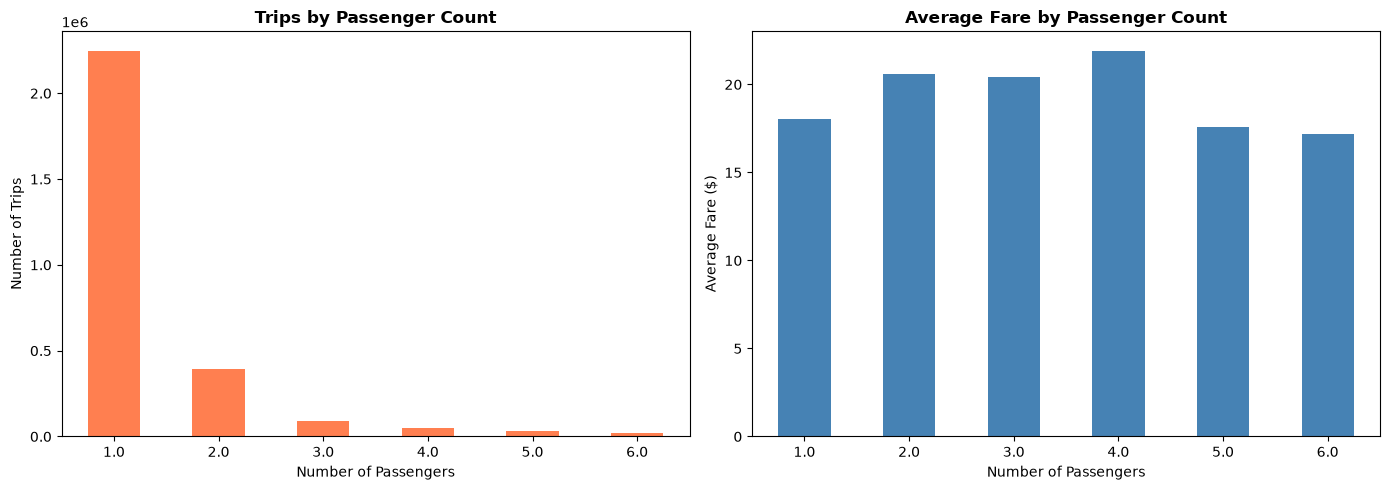

In [64]:
passenger_stats = df_clean.groupby('passenger_count').agg({
    'VendorID': 'count',
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'tip_percentage': 'mean'
}).rename(columns={'VendorID': 'trip_count'})

print("\n=== PASSENGER COUNT ANALYSIS ===")
print(passenger_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip count by passenger count
passenger_stats['trip_count'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Trips by Passenger Count', fontweight='bold')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xlabel('Number of Passengers')
axes[0].tick_params(axis='x', rotation=0)

# Average fare by passenger count
passenger_stats['fare_amount'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Fare by Passenger Count', fontweight='bold')
axes[1].set_ylabel('Average Fare ($)')
axes[1].set_xlabel('Number of Passengers')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


=== SPEED STATISTICS ===
count    2.836888e+06
mean     1.153747e+01
std      6.772012e+00
min      4.841964e-03
25%      7.397260e+00
50%      9.678652e+00
75%      1.314250e+01
max      6.000000e+01
Name: speed_mph, dtype: float64


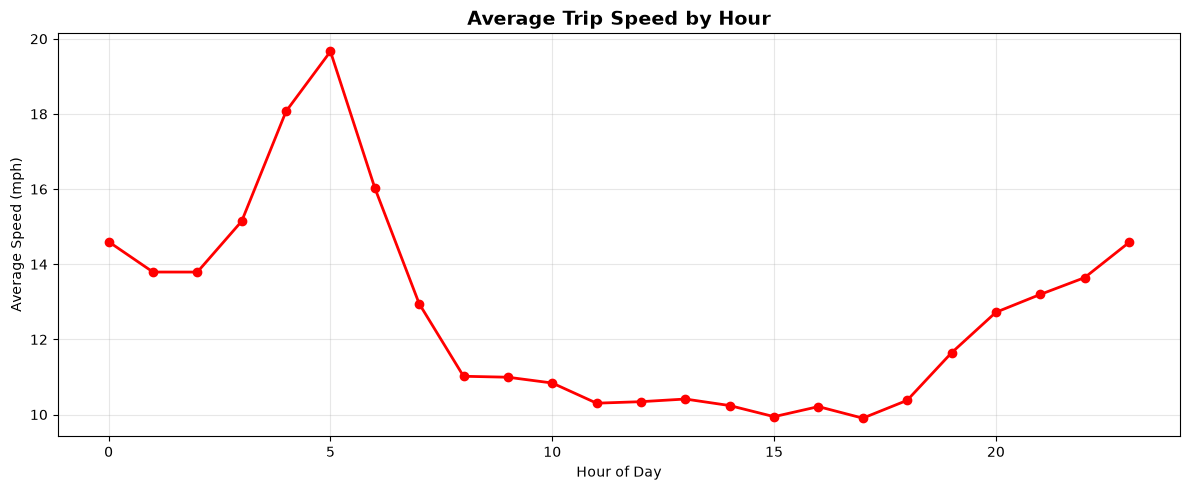


Fastest average hour: 5:00 (19.7 mph)
Slowest average hour: 17:00 (9.9 mph)


In [65]:
print("\n=== SPEED STATISTICS ===")
print(df_clean['speed_mph'].describe())

# Speed by hour
speed_by_hour = df_clean.groupby('pickup_hour')['speed_mph'].mean()

plt.figure(figsize=(12, 5))
plt.plot(speed_by_hour.index, speed_by_hour.values, marker='o', linewidth=2, color='red')
plt.xlabel('Hour of Day')
plt.ylabel('Average Speed (mph)')
plt.title('Average Trip Speed by Hour', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFastest average hour: {speed_by_hour.idxmax()}:00 ({speed_by_hour.max():.1f} mph)")
print(f"Slowest average hour: {speed_by_hour.idxmin()}:00 ({speed_by_hour.min():.1f} mph)")

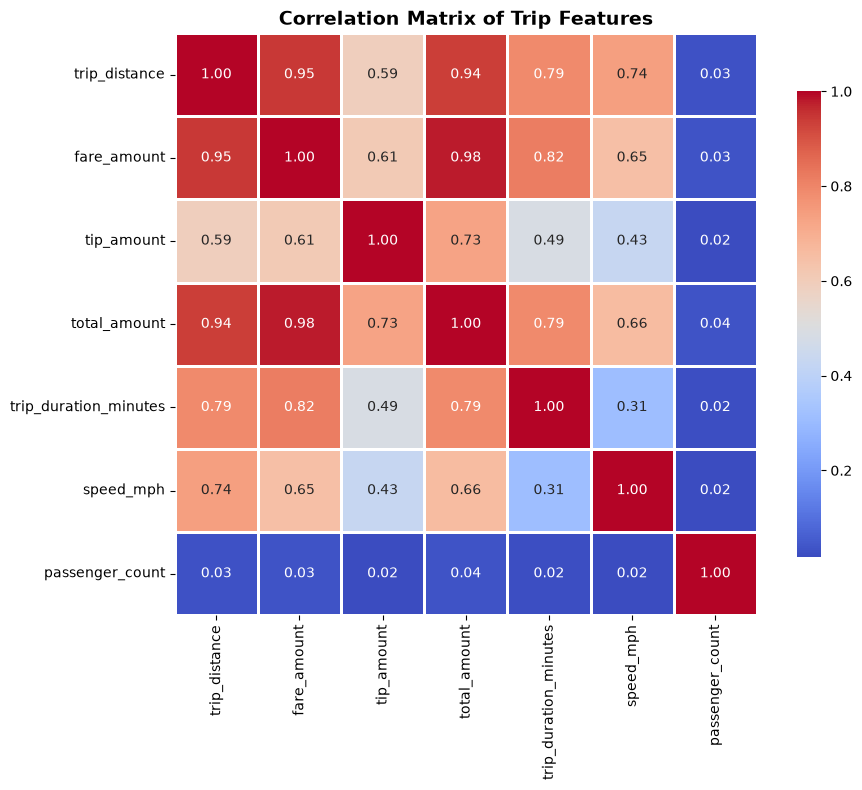


=== KEY CORRELATIONS ===
Strongest positive correlations:
total_amount           fare_amount      0.978616
fare_amount            trip_distance    0.945259
total_amount           trip_distance    0.936680
trip_duration_minutes  fare_amount      0.816001
                       trip_distance    0.791519
dtype: float64


In [68]:
# Select numeric columns for correlation
numeric_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 
                'trip_duration_minutes', 'speed_mph', 'passenger_count']

correlation_matrix = df_clean[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Trip Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== KEY CORRELATIONS ===")
print("Strongest positive correlations:")
# Get upper triangle of correlation matrix
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
corr_pairs = correlation_matrix.where(~mask).stack().sort_values(ascending=False)
print(corr_pairs.head(5))

In [67]:
import seaborn as sns

In [69]:
print("\n" + "="*60)
print("NYC YELLOW TAXI - MONTH 1 ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total trips analyzed: {len(df_clean):,}")
print(f"   Date range: {df_clean['tpep_pickup_datetime'].min().date()} to {df_clean['tpep_pickup_datetime'].max().date()}")
print(f"   Data quality: {(len(df_clean)/len(df)*100):.1f}% of original data retained")

print(f"\n💰 FINANCIAL METRICS")
print(f"   Total revenue: ${df_clean['total_amount'].sum():,.2f}")
print(f"   Average fare: ${df_clean['fare_amount'].mean():.2f}")
print(f"   Average tip: ${df_clean['tip_amount'].mean():.2f}")
print(f"   Average total: ${df_clean['total_amount'].mean():.2f}")

print(f"\n🚕 TRIP CHARACTERISTICS")
print(f"   Average distance: {df_clean['trip_distance'].mean():.2f} miles")
print(f"   Average duration: {df_clean['trip_duration_minutes'].mean():.1f} minutes")
print(f"   Average speed: {df_clean['speed_mph'].mean():.1f} mph")
print(f"   Average passengers: {df_clean['passenger_count'].mean():.1f}")

print(f"\n⏰ TEMPORAL PATTERNS")
print(f"   Busiest hour: {df_clean.groupby('pickup_hour').size().idxmax()}:00")
print(f"   Busiest day: {df_clean.groupby('day_name').size().idxmax()}")
print(f"   Weekend vs Weekday: {(df_clean['is_weekend'].sum()/len(df_clean)*100):.1f}% weekend trips")

print(f"\n💳 PAYMENT PREFERENCES")
payment_dist = df_clean['payment_type'].value_counts(normalize=True) * 100
print(f"   Credit card: {payment_dist.get(1, 0):.1f}%")
print(f"   Cash: {payment_dist.get(2, 0):.1f}%")

print("\n" + "="*60)


NYC YELLOW TAXI - MONTH 1 ANALYSIS SUMMARY

📊 DATASET OVERVIEW
   Total trips analyzed: 2,836,888
   Date range: 2002-12-31 to 2024-02-01
   Data quality: 95.7% of original data retained

💰 FINANCIAL METRICS
   Total revenue: $77,616,795.97
   Average fare: $18.50
   Average tip: $3.41
   Average total: $27.36

🚕 TRIP CHARACTERISTICS
   Average distance: 3.30 miles
   Average duration: 15.0 minutes
   Average speed: 11.5 mph
   Average passengers: 1.3

⏰ TEMPORAL PATTERNS
   Busiest hour: 18:00
   Busiest day: Wednesday
   Weekend vs Weekday: 25.6% weekend trips

💳 PAYMENT PREFERENCES
   Credit card: 80.1%
   Cash: 14.7%



In [70]:
# Save cleaned data
df_clean.to_csv('nyc_taxi_2024_01_cleaned.csv', index=False)
print("✅ Cleaned data saved to: nyc_taxi_2024_01_cleaned.csv")

# Save summary statistics
summary_stats = {
    'Total Trips': len(df_clean),
    'Total Revenue': df_clean['total_amount'].sum(),
    'Avg Fare': df_clean['fare_amount'].mean(),
    'Avg Distance': df_clean['trip_distance'].mean(),
    'Avg Duration': df_clean['trip_duration_minutes'].mean(),
    'Avg Speed': df_clean['speed_mph'].mean()
}

summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv('nyc_taxi_2024_01_summary.csv', index=False)
print("✅ Summary statistics saved to: nyc_taxi_2024_01_summary.csv")

# Save daily aggregates for time series
daily_stats.to_csv('nyc_taxi_2024_01_daily.csv', index=False)
print("✅ Daily statistics saved to: nyc_taxi_2024_01_daily.csv")

✅ Cleaned data saved to: nyc_taxi_2024_01_cleaned.csv
✅ Summary statistics saved to: nyc_taxi_2024_01_summary.csv
✅ Daily statistics saved to: nyc_taxi_2024_01_daily.csv


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("LOADING ALL 2024 NYC TAXI DATA")
print("="*60)

# Find all parquet files
files = sorted(glob.glob("C:/DataAnalytics/NYC_Taxi_Analysis/data/raw"))

print(f"\nFound {len(files)} files:")
for f in files:
    print(f"  • {f}")

# Load and combine all files
print("\n⏳ Loading all files... (this may take a few minutes)")
df_list = []
for file in files:
    df_month = pd.read_parquet(file)
    df_list.append(df_month)
    print(f"  ✓ Loaded {file}: {len(df_month):,} rows")

# Combine all months
df = pd.concat(df_list, ignore_index=True)

print(f"\n✅ Total data loaded: {len(df):,} rows")
print(f"   Date range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("="*60)

LOADING ALL 2024 NYC TAXI DATA

Found 1 files:
  • C:/DataAnalytics/NYC_Taxi_Analysis/data/raw

⏳ Loading all files... (this may take a few minutes)
  ✓ Loaded C:/DataAnalytics/NYC_Taxi_Analysis/data/raw: 41,169,720 rows

✅ Total data loaded: 41,169,720 rows
   Date range: 2002-12-31 16:46:07 to 2026-06-26 23:53:12
   Memory usage: 5533.3 MB


In [72]:
# Load just January to test
test_file = 'C:/DataAnalytics/NYC_Taxi_Analysis/data/raw/yellow_tripdata_2024-01.parquet'

df_test = pd.read_parquet(test_file)

print(f"January 2024 file:")
print(f"  Rows: {len(df_test):,}")
print(f"  Date range: {df_test['tpep_pickup_datetime'].min()} to {df_test['tpep_pickup_datetime'].max()}")
print(f"\n  Year distribution:")
print(df_test['tpep_pickup_datetime'].dt.year.value_counts().sort_index())

January 2024 file:
  Rows: 2,964,624
  Date range: 2002-12-31 22:59:39 to 2024-02-01 00:01:15

  Year distribution:
tpep_pickup_datetime
2002          2
2009          3
2023         10
2024    2964609
Name: count, dtype: int64


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("LOADING ALL 2024 NYC TAXI DATA")
print("="*60)

# Find all parquet files
files = sorted(glob.glob('C:/DataAnalytics/NYC_Taxi_Analysis/data/raw/*.parquet'))

print(f"\nFound {len(files)} files:")
for f in files:
    print(f"  • {os.path.basename(f)}")

# Load and combine all files
print("\n⏳ Loading all files... (this may take a few minutes)")
df_list = []
total_rows_before = 0
total_rows_after = 0

for file in files:
    df_month = pd.read_parquet(file)
    rows_before = len(df_month)
    total_rows_before += rows_before
    
    # Filter to ONLY valid 2024 dates
    df_month = df_month[
        (df_month['tpep_pickup_datetime'] >= '2024-01-01') &
        (df_month['tpep_pickup_datetime'] <= '2024-12-31')
    ].copy()
    
    rows_after = len(df_month)
    total_rows_after += rows_after
    removed = rows_before - rows_after
    
    df_list.append(df_month)
    print(f"  ✓ Loaded {os.path.basename(file)}: {rows_after:,} rows (removed {removed} bad dates)")

# Combine all months
df = pd.concat(df_list, ignore_index=True)

print(f"\n✅ Total data loaded: {len(df):,} rows")
print(f"   Removed {total_rows_before - total_rows_after:,} rows with invalid dates")
print(f"   Date range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Final verification
print(f"\n🔍 Data Verification:")
year_counts = df['tpep_pickup_datetime'].dt.year.value_counts().sort_index()
print(f"   Years in dataset:")
for year, count in year_counts.items():
    print(f"      {year}: {count:,} rows ({count/len(df)*100:.1f}%)")

if len(year_counts) == 1 and year_counts.index[0] == 2024:
    print(f"\n   ✅ All data is from 2024!")
else:
    print(f"\n   ⚠️  Warning: Still have data from other years!")

print("="*60)

LOADING ALL 2024 NYC TAXI DATA

Found 12 files:
  • yellow_tripdata_2024-01.parquet
  • yellow_tripdata_2024-02.parquet
  • yellow_tripdata_2024-03.parquet
  • yellow_tripdata_2024-04.parquet
  • yellow_tripdata_2024-05.parquet
  • yellow_tripdata_2024-06.parquet
  • yellow_tripdata_2024-07.parquet
  • yellow_tripdata_2024-08.parquet
  • yellow_tripdata_2024-09.parquet
  • yellow_tripdata_2024-10.parquet
  • yellow_tripdata_2024-11.parquet
  • yellow_tripdata_2024-12.parquet

⏳ Loading all files... (this may take a few minutes)
  ✓ Loaded yellow_tripdata_2024-01.parquet: 2,964,609 rows (removed 15 bad dates)
  ✓ Loaded yellow_tripdata_2024-02.parquet: 3,007,524 rows (removed 2 bad dates)
  ✓ Loaded yellow_tripdata_2024-03.parquet: 3,582,626 rows (removed 2 bad dates)
  ✓ Loaded yellow_tripdata_2024-04.parquet: 3,514,285 rows (removed 4 bad dates)
  ✓ Loaded yellow_tripdata_2024-05.parquet: 3,723,826 rows (removed 7 bad dates)
  ✓ Loaded yellow_tripdata_2024-06.parquet: 3,539,187 rows (

In [74]:
print("\n" + "="*60)
print("DATA CLEANING - FULL YEAR")
print("="*60)

# Check missing values
print("\n📊 Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

# Fill missing values
print("\n🔧 Filling missing values...")
df_clean = df.fillna({
    'passenger_count': 1,
    'RatecodeID': 1,
    'Airport_fee': 0,
    'congestion_surcharge': 0,
    'store_and_fwd_flag': 'N'
})

# Calculate trip duration
df_clean['trip_duration_minutes'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Apply quality filters
initial_count = len(df_clean)

df_clean = df_clean[
    (df_clean['fare_amount'] > 0) &
    (df_clean['fare_amount'] < 500) &
    (df_clean['trip_distance'] > 0) &
    (df_clean['trip_distance'] < 100) &
    (df_clean['passenger_count'] > 0) &
    (df_clean['passenger_count'] <= 6) &
    (df_clean['trip_duration_minutes'] > 0) &
    (df_clean['trip_duration_minutes'] < 180)
]

removed = initial_count - len(df_clean)
print(f"\n📉 Removed {removed:,} rows ({removed/initial_count*100:.2f}%)")
print(f"✅ Clean dataset: {len(df_clean):,} trips ({len(df_clean)/len(df)*100:.1f}% of original)")

print("="*60)


DATA CLEANING - FULL YEAR

📊 Missing values:
                      Missing_Count  Percentage
store_and_fwd_flag          4080949    9.933916
RatecodeID                  4080949    9.933916
passenger_count             4080949    9.933916
Airport_fee                 4080949    9.933916
congestion_surcharge        4080949    9.933916

🔧 Filling missing values...

📉 Removed 1,868,461 rows (4.55%)
✅ Clean dataset: 39,212,507 trips (95.5% of original)
